# **Import libraries** #

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("imported sucessfully")

imported sucessfully


# **Import Scikit-Learn tools (splitting, scaling, model, metrics)** #

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# **Import statistical utilities for VIF analysis** #

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# **Configure visualization aesthetics and display formats** #

In [8]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

# **Data Loading & Initial Structural Inspection** #

In [12]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [13]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [14]:
rows, cols = df.shape
print(f"Total Rows: {rows}, Total Columns: {cols}")

Total Rows: 545, Total Columns: 13


In [15]:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [16]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [77]:
df = df.rename(columns={'bedrooms': 'bed-rooms'})
df = df.rename(columns={'bathrooms': 'bath-rooms'})
df = df.rename(columns={'mainroad': 'main-road'})
df = df.rename(columns={'guestroom': 'guest-room'})
df = df.rename(columns={'hotwaterheating': 'hot-water-heating'})
df = df.rename(columns={'prefarea': 'pref-area'})
df = df.rename(columns={'furnishingstatus': 'furnishing-status'})
df = df.rename(columns={'airconditioning': 'air-condisioner'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   price              545 non-null    int64 
 1   area               545 non-null    int64 
 2   bed-rooms          545 non-null    int64 
 3   bath-rooms         545 non-null    int64 
 4   stories            545 non-null    int64 
 5   main-road          545 non-null    object
 6   guest-room         545 non-null    object
 7   basement           545 non-null    object
 8   hot-water-heating  545 non-null    object
 9   air-condisioner    545 non-null    object
 10  parking            545 non-null    int64 
 11  pref-area          545 non-null    object
 12  furnishing-status  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# **Data Quality Auditing & Summary Statistics** #

In [78]:
df.isnull().sum()

price                0
area                 0
bed-rooms            0
bath-rooms           0
stories              0
main-road            0
guest-room           0
basement             0
hot-water-heating    0
air-condisioner      0
parking              0
pref-area            0
furnishing-status    0
dtype: int64

In [79]:
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

Total Duplicate Rows: 0


In [80]:
df.describe()

,price,area,bed-rooms,bath-rooms,stories,parking
count,545.000,545.000,545.000,545.000,545.000,545.000
mean,4766729.248,5150.541,2.965,1.286,1.806,0.694
std,1870439.616,2170.141,0.738,0.502,0.867,0.862
min,1750000.000,1650.000,1.000,1.000,1.000,0.000
25%,3430000.000,3600.000,2.000,1.000,1.000,0.000
50%,4340000.000,4600.000,3.000,1.000,2.000,0.000
75%,5740000.000,6360.000,3.000,2.000,2.000,1.000
max,13300000.000,16200.000,6.000,4.000,4.000,3.000


In [81]:
df.describe(include=['object'])

,main-road,guest-room,basement,hot-water-heating,air-condisioner,pref-area,furnishing-status
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [82]:
df['furnishing-status'].value_counts()

furnishing-status
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [84]:
for col in ['main-road', 'guest-room', 'basement', 'hot-water-heating', 'air-condisioner', 'pref-area']:
    print(df[col].value_counts())
    print("-" * 30)

main-road
yes    468
no      77
Name: count, dtype: int64
------------------------------
guest-room
no     448
yes     97
Name: count, dtype: int64
------------------------------
basement
no     354
yes    191
Name: count, dtype: int64
------------------------------
hot-water-heating
no     520
yes     25
Name: count, dtype: int64
------------------------------
air-condisioner
no     373
yes    172
Name: count, dtype: int64
------------------------------
pref-area
no     417
yes    128
Name: count, dtype: int64
------------------------------


# **Visual Exploratory Data Analysis (EDA)** #

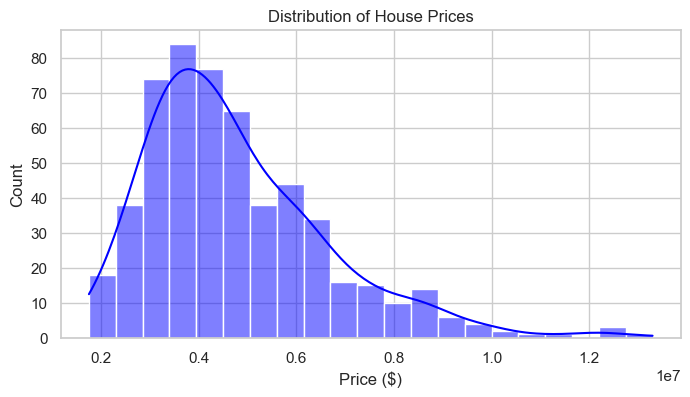

In [85]:
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

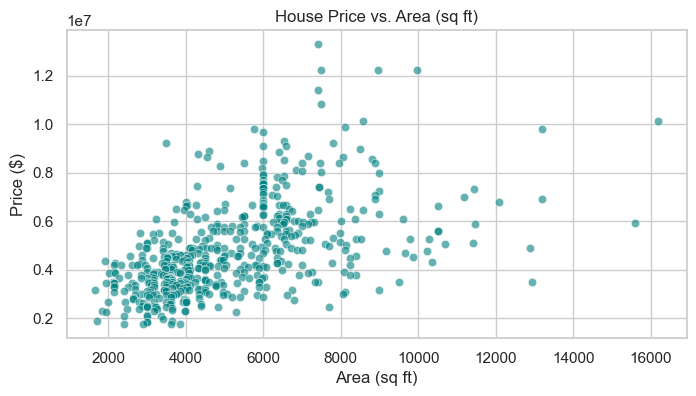

In [86]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x=df['area'], y=df['price'], alpha=0.6, color='teal')
plt.title('House Price vs. Area (sq ft)')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.show()

C:\Users\AMEENA RIHA\AppData\Local\Temp\ipykernel_16328\2558051883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['bed-rooms'], y=df['price'], palette='Blues')


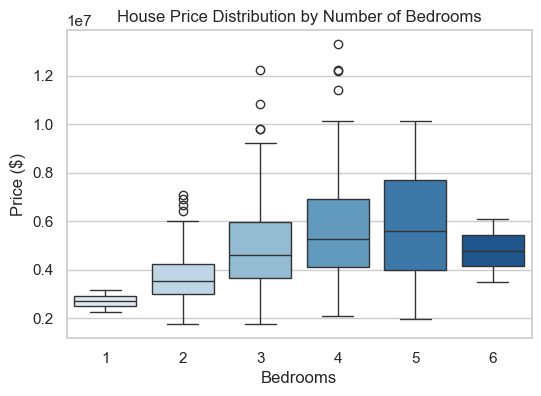

In [90]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['bed-rooms'], y=df['price'], palette='Blues')
plt.title('House Price Distribution by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price ($)')
plt.show()

C:\Users\AMEENA RIHA\AppData\Local\Temp\ipykernel_16328\3204233421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['bath-rooms'], y=df['price'], palette='Greens')


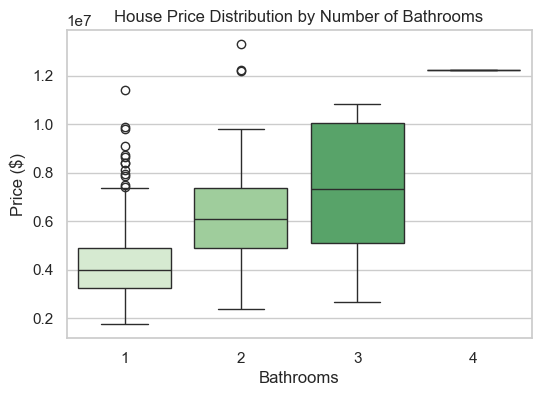

In [91]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['bath-rooms'], y=df['price'], palette='Greens')
plt.title('House Price Distribution by Number of Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Price ($)')
plt.show()

C:\Users\AMEENA RIHA\AppData\Local\Temp\ipykernel_16328\568615362.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['furnishing-status'], y=df['price'], palette='Set2')


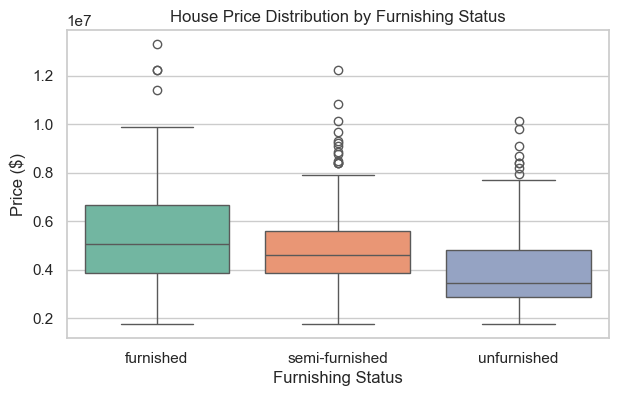

In [92]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df['furnishing-status'], y=df['price'], palette='Set2')
plt.title('House Price Distribution by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Price ($)')
plt.show()

# **Categorical Encoding & Feature Transformation** #

In [93]:
df_encoded = df.copy()

In [94]:
binary_cols = ['main-road', 'guest-room', 'basement', 'hot-water-heating', 'air-condisioner', 'pref-area']

In [95]:
binary_map = {'yes': 1, 'no': 0}

In [96]:
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)

In [97]:
df_encoded[binary_cols].head()

,main-road,guest-room,basement,hot-water-heating,air-condisioner,pref-area
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [98]:
df_encoded = pd.get_dummies(df_encoded, columns=['furnishing-status'], drop_first=True, dtype=int)

In [99]:
df_encoded.head()

,price,area,bed-rooms,bath-rooms,stories,main-road,guest-room,basement,hot-water-heating,air-condisioner,parking,pref-area,furnishing-status_semi-furnished,furnishing-status_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [100]:
df_encoded.dtypes

price                               int64
area                                int64
bed-rooms                           int64
bath-rooms                          int64
stories                             int64
main-road                           int64
guest-room                          int64
basement                            int64
hot-water-heating                   int64
air-condisioner                     int64
parking                             int64
pref-area                           int64
furnishing-status_semi-furnished    int64
furnishing-status_unfurnished       int64
dtype: object

In [101]:
corr_matrix = df_encoded.corr()

In [102]:
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr)

price                               1.000
area                                0.536
bath-rooms                          0.518
air-condisioner                     0.453
stories                             0.421
parking                             0.384
bed-rooms                           0.366
pref-area                           0.330
main-road                           0.297
guest-room                          0.256
basement                            0.187
hot-water-heating                   0.093
furnishing-status_semi-furnished    0.064
furnishing-status_unfurnished      -0.281
Name: price, dtype: float64


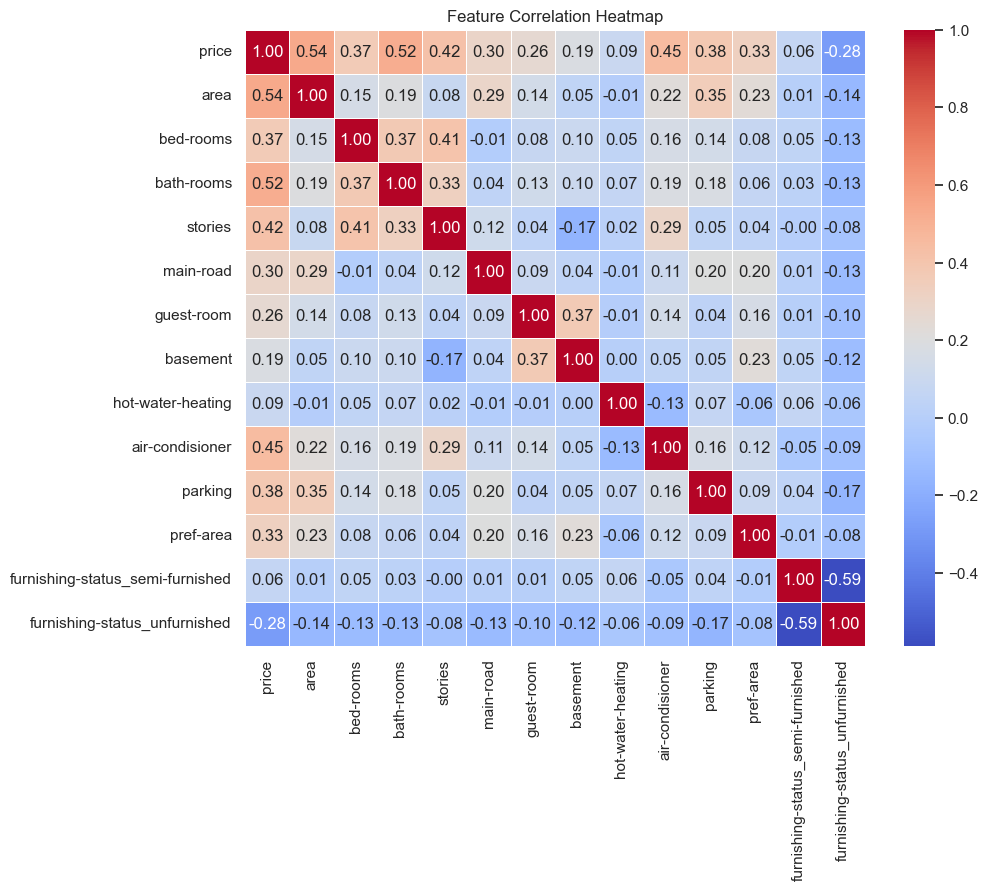

In [103]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [104]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [105]:
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (545, 13), y shape: (545,)


In [106]:
def get_vif_dataframe(predictor_matrix):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = predictor_matrix.columns
    vif_data["VIF"] = [variance_inflation_factor(predictor_matrix.values, i) for i in range(predictor_matrix.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

In [107]:
vif_scores = get_vif_dataframe(X)
print(vif_scores)

                             Feature    VIF
1                          bed-rooms 16.652
2                         bath-rooms  9.418
0                               area  8.276
3                            stories  7.881
4                          main-road  6.885
11  furnishing-status_semi-furnished  2.387
6                           basement  2.020
12     furnishing-status_unfurnished  2.009
9                            parking  1.986
8                    air-condisioner  1.768
10                         pref-area  1.494
5                         guest-room  1.473
7                  hot-water-heating  1.092


C:\Users\AMEENA RIHA\AppData\Local\Temp\ipykernel_16328\1520742267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_scores, x='VIF', y='Feature', palette='Reds_r')


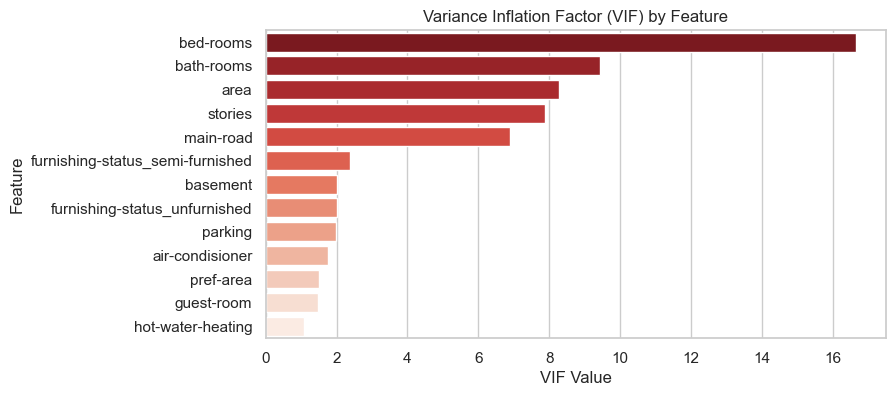

In [108]:
plt.figure(figsize=(8, 4))
sns.barplot(data=vif_scores, x='VIF', y='Feature', palette='Reds_r')
plt.title('Variance Inflation Factor (VIF) by Feature')
plt.xlabel('VIF Value')
plt.show()

# **Train-Test Splitting** #

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [110]:
print(f"X_train shape: {X_train.shape}")

X_train shape: (436, 13)


In [111]:
print(f"X_test shape: {X_test.shape}")

X_test shape: (109, 13)


In [112]:
print(f"y_train shape: {y_train.shape}")

y_train shape: (436,)


In [113]:
print(f"y_test shape: {y_test.shape}")

y_test shape: (109,)


# **Feature Normalization / Standardization** #

In [114]:
scaler = StandardScaler()

In [115]:
X_train_scaled = scaler.fit_transform(X_train)

In [116]:
X_test_scaled = scaler.transform(X_test)

In [117]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

In [118]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [119]:
X_train_scaled_df.describe().loc[['mean', 'std']].round(4)

,area,bed-rooms,bath-rooms,stories,main-road,guest-room,basement,hot-water-heating,air-condisioner,parking,pref-area,furnishing-status_semi-furnished,furnishing-status_unfurnished
mean,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


# **Model Training & Coefficient Analysis** #

In [120]:
model = LinearRegression()

In [121]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [122]:
print(f"Model Intercept (y-intercept): ${model.intercept_:,.2f}")

Model Intercept (y-intercept): $4,706,527.39


In [123]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
2,bath-rooms,521879.028
0,area,519552.416
8,air-condisioner,365157.394
3,stories,349251.439
10,pref-area,266656.352
9,parking,192005.954
6,basement,187067.803
7,hot-water-heating,149862.703
4,main-road,128498.628
5,guest-room,88768.668


C:\Users\AMEENA RIHA\AppData\Local\Temp\ipykernel_16328\3981893907.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')


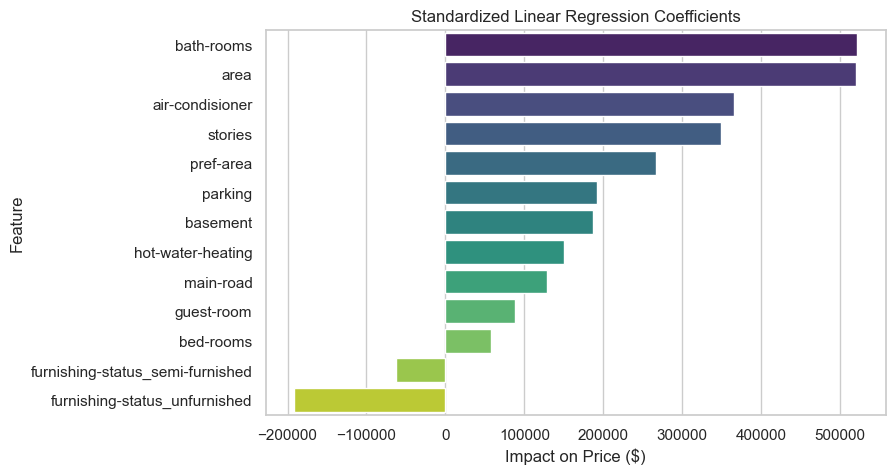

In [124]:
plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')
plt.title('Standardized Linear Regression Coefficients')
plt.xlabel('Impact on Price ($)')
plt.show()

# **Conclusion** #

##
The linear model hit an $R^2$ of about 0.65, meaning it captures around 65% of what drives house prices in this dataset.Square footage (area) and the number of bathrooms were by far the biggest heavy hitters for price, closely followed by having an air-condisioner and more stories. Overall, it gives a solid, easy-to-read baseline for predicting prices, though switching to something like Random Forest later on could help pick up on non-linear price jumps.